# Student Success Model Example 1

In [1]:
stu <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/student success (2).csv", header=TRUE)
head(stu)
stu$success<-factor(stu$success) # make success a factor
# divide into train and test data
set.seed(23)
R=runif(nrow(stu)) #create a random uniform column the length of our table
stu$R=R #add the random numbers to our table
train<-stu[stu$R<=.6,] #select roughly 60% for training
test<-stu[stu$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

,Student,FinalGrade1403,Transfer,ACT_Score,ACT_Math,HS_GPA,success
,<int>,<int>,<chr>,<int>,<int>,<dbl>,<chr>
1,1,83,no,23,14,3.58,yes
2,2,98,yes,30,32,3.60,yes
3,3,89,no,24,21,2.77,yes
4,4,47,no,21,24,2.89,no
5,5,91,no,24,18,2.85,yes
6,6,78,no,31,31,3.52,yes


Warning message:
"package 'rpart' was built under R version 4.5.3"
Warning message:
"package 'rpart.plot' was built under R version 4.5.3"


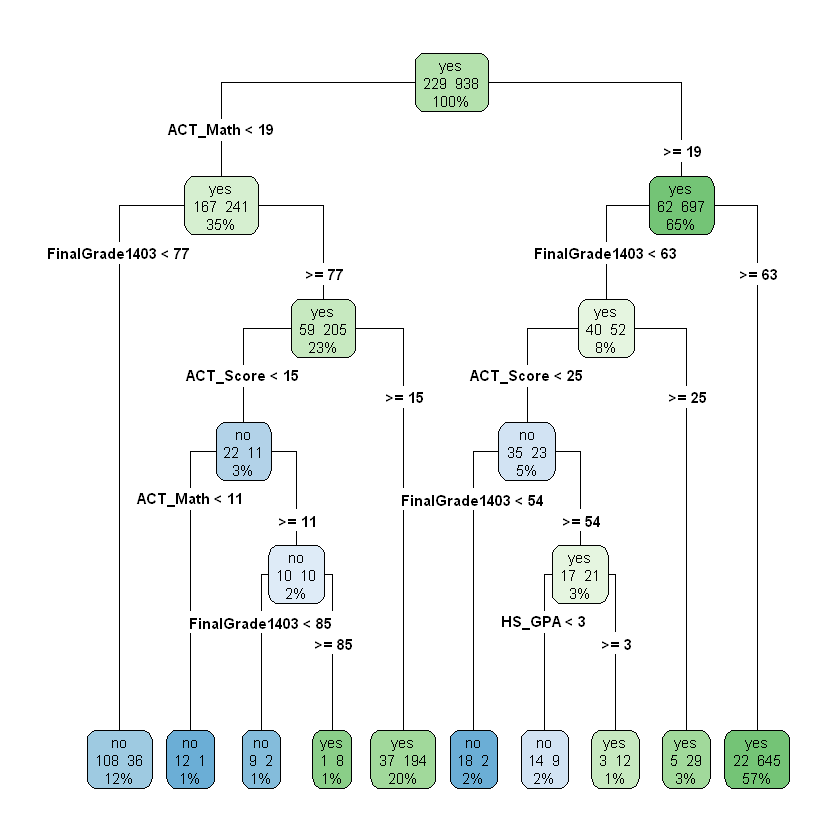

In [2]:
# ========================================================================
# classification tree
#install.packages('rpart', dependencies = TRUE) #this should be done from earlier this semester 
#install.packages('rpart.plot', dependencies = TRUE) #this should be done from earlier this semester 
library(rpart)
library(rpart.plot)
ctree<-rpart(success~FinalGrade1403+Transfer+ACT_Score+ACT_Math+HS_GPA,data=train)
rpart.plot(ctree, type = 4, extra = 101)
# ========================================================================

In [3]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# fit the model to the test data
model<- predict(ctree, newdata=test, type = "class")
known<-test["success"] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      model
knownt  no yes
   no  102  67
   yes  56 608

# Random Forest

If you create the random forest immediately after the classification tree, this first part is not necessary  to run again (the same train and test tables from earlier will still be there)

In [4]:
# repeat of classification tree
stu <- read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/student success (2).csv", header=TRUE)
stu$success <- factor(stu$success)
# divide into train and test data
set.seed(23)
R=runif(nrow(stu)) #create a random uniform column the length of our table
stu$R=R #add the random numbers to our table
train<-stu[stu$R<=.6,] #select roughly 60% for training
test<-stu[stu$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

In [7]:
library(randomForest)
set.seed(23)
RFM <- randomForest(success ~ FinalGrade1403 + Transfer + ACT_Score + ACT_Math + HS_GPA, data = train)
model <- predict(RFM, newdata = test, type = "class")
known  <- test["success"]
knownt <- t(known)
table(knownt, model)

newdata=data.frame(FinalGrade1403=59,Transfer="yes",ACT_Score=23,ACT_Math=24,HS_GPA=2.7)
newdata$Transfer <- factor(newdata$Transfer, levels = levels(train$Transfer))
#random forests are particular about factors in input data sets
predict(RFM,newdata=newdata,type="class")

# Build newdata and match ALL factor levels from train
newdata <- data.frame(
    FinalGrade1403 = 59,
    Transfer       = factor("yes", levels = levels(train$Transfer)),
    ACT_Score      = 23,
    ACT_Math       = 24,
    HS_GPA         = 2.7
)

predict(RFM, newdata = newdata, type = "class")

      model
knownt  no yes
   no  105  64
   yes  47 617

ERROR: Error in predict.randomForest(RFM, newdata = newdata, type = "class"): Type of predictors in new data do not match that of the training data.


# ANN

In [6]:
# Divide into train and test data sets
set.seed(23)
R=runif(nrow(stu)) #create a random uniform column the length of our table
stu$R=R #add the random numbers to our table
train<-stu[stu$R<=.6,] #select roughly 60% for training
test<-stu[stu$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

In [7]:
num_input_cols <- ncol(train)
num_input_cols

[1] 7

In [8]:
size <- ((2/3) * (num_input_cols + 1))

library(nnet)
set.seed(17)
ANN<-nnet(success~FinalGrade1403+Transfer+ACT_Score+ACT_Math+HS_GPA, # same forumla as class tree and random forrest
          data=train, 
          size=size # ((2/3) * (num_input_cols + 1 output_col))
         ) 

Warning message:
"package 'nnet' was built under R version 4.5.3"


# weights:  36
initial  value 1162.941178 
final  value 577.817844 
converged


Notice the formula stays the same regardless of whether we are using a
logistic regression model, a decision tree, a random forest or a ANN. The
set.seed controls the random weights that are used as initial guesses
(makes the program repeatable). Size=4 refers to the number of neurons
to use in the hidden layer of the ANN. Like “mtry” for random forests,
there is no absolute value to use for size. One rule of thumb is two use
the 2/3 the number of inputs plus the number of outputs:
5 input columns+1 output column = 6.
.667*6 is approximately 4.

In [9]:
# fit the model to the testing data
model<- predict(ANN, newdata=test, type = "class")
known<-test["success"] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

      model
knownt yes
   no  169
   yes 664

# Appt Example 2

In [10]:
appt <-read.csv("C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/BDA Spring 26/Datasets/appt (1).csv", header=TRUE)
head(appt)
colnames(appt)
appt$MissedAppt<-factor(appt$MissedAppt) # make MissedAppt a factor
# divide into train and test data
set.seed(23)
R=runif(nrow(appt)) #create a random uniform column the length of our table
appt$R=R #add the random numbers to our table
train<-appt[appt$R<=.6,] #select roughly 60% for training
test<-appt[appt$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

,MissedAppt,PrevMissedAppt,SameDayAppt,Age,Male,White,WaitTime,Monday,Tuesday,Thursday,Friday,Saturday
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,no,no,no,42,yes,no,46,no,no,no,yes,no
2,yes,no,no,37,no,no,6,no,yes,no,no,no
3,no,no,no,32,yes,no,98,no,no,no,no,yes
4,yes,no,no,53,yes,no,14,no,yes,no,no,no
5,no,no,no,15,no,yes,22,no,no,no,yes,no
6,yes,no,yes,52,no,no,25,no,no,no,no,no


[1] "MissedAppt"     "PrevMissedAppt" "SameDayAppt"    "Age"           
 [5] "Male"           "White"          "WaitTime"       "Monday"        
 [9] "Tuesday"        "Thursday"       "Friday"         "Saturday"

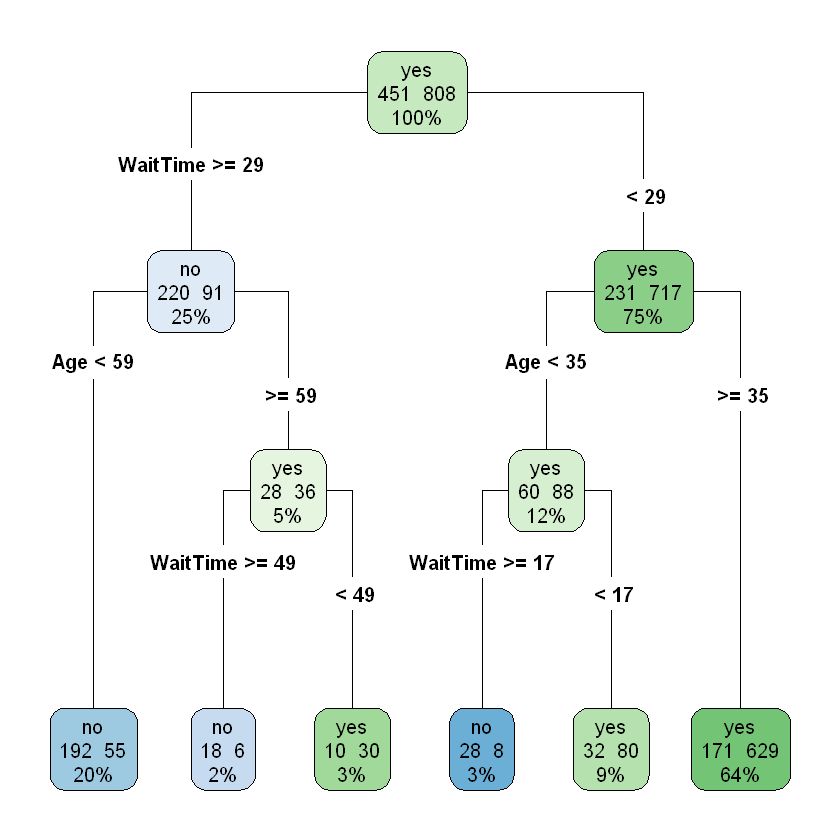

In [11]:
# ========================================================================
# classification tree
#install.packages('rpart', dependencies = TRUE) #this should be done from earlier this semester 
#install.packages('rpart.plot', dependencies = TRUE) #this should be done from earlier this semester 
library(rpart)
library(rpart.plot)
ctree<-rpart(MissedAppt~.,data=train)
rpart.plot(ctree, type = 4, extra = 101)
# ========================================================================

In [12]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# fit the model to the test data
model<- predict(ctree, newdata=test, type = "class")
known<-test["MissedAppt"] #extract the actual value of MissedAppt for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      model
knownt  no yes
   no  156 154
   yes  63 523

In [13]:
# making a prediction using R Class Tree
newdata=data.frame(
    PrevMissedAppt="no",
    SameDayAppt="yes", 
    Age=47, 
    Male="yes", 
    White="yes", 
    WaitTime=30,
    Monday="yes", 
    Tuesday="no", 
    Thursday="no",
    Friday="no", 
    Saturday="no"
)

predict(ctree,newdata=newdata,type="class")

1 
no 
Levels: no yes

# Random Forest

In [14]:
library(randomForest)
set.seed(23)
RFM <- randomForest(MissedAppt~., data = train)
model <- predict(RFM, newdata = test, type = "class")
known  <- test["MissedAppt"]
knownt <- t(known)
table(knownt, model)

      model
knownt  no yes
   no  157 153
   yes  50 536

In [15]:
# predict
#out of the techniques we will look at only Random Forests require factors to be labeled for a new prediction
newdata$PrevMissedAppt <- factor(newdata$PrevMissedAppt, levels = levels(train$PrevMissedAppt))
newdata$SameDayAppt <- factor(newdata$SameDayAppt, levels = levels(train$SameDayAppt))
newdata$Male <- factor(newdata$Male, levels = levels(train$Male))
newdata$White <- factor(newdata$White, levels = levels(train$White))
newdata$Monday <- factor(newdata$Monday, levels = levels(train$Monday))
newdata$Tuesday <- factor(newdata$Tuesday, levels = levels(train$Tuesday))
newdata$Thursday <- factor(newdata$Thursday, levels = levels(train$Thursday))
newdata$Friday <- factor(newdata$Friday, levels = levels(train$Friday))
newdata$Saturday <- factor(newdata$Saturday, levels = levels(train$Saturday))
predict(RFM,newdata=newdata,type="class")

ERROR: Error in predict.randomForest(RFM, newdata = newdata, type = "class"): Type of predictors in new data do not match that of the training data.


# ANN

In [16]:
# Divide into train and test data sets
set.seed(23)
R=runif(nrow(appt)) #create a random uniform column the length of our table
appt$R=R #add the random numbers to our table
train<-appt[appt$R<=.6,] #select roughly 60% for training
test<-appt[appt$R>.6,] #the other 40% gets placed in test
train<-subset(train,select=-c(R)) #remove the column R
test<-subset(test,select=-c(R)) #remove the column R

In [19]:
size <- ((2/3) * (num_input_cols + 1))

library(nnet)
set.seed(17)
ANN<-nnet(MissedAppt~., # same forumla as class tree and random forrest
          data=train, 
          size=size # ((2/3) * (num_input_cols + 1 output_col))
         ) 

# weights:  66
initial  value 1618.328321 
iter  10 value 668.349864
iter  20 value 651.644479
iter  30 value 613.914896
iter  40 value 605.906034
iter  50 value 605.448613
final  value 605.447936 
converged


Notice the formula stays the same regardless of whether we are using a
logistic regression model, a decision tree, a random forest or a ANN. The
set.seed controls the random weights that are used as initial guesses
(makes the program repeatable). Size=4 refers to the number of neurons
to use in the hidden layer of the ANN. Like “mtry” for random forests,
there is no absolute value to use for size. One rule of thumb is two use
the 2/3 the number of inputs plus the number of outputs:
5 input columns+1 output column = 6.
.667*6 is approximately 4.

In [20]:
# fit the model to the testing data
model<- predict(ANN, newdata=test, type = "class")
known<-test["MissedAppt"] #extract the actual value of success for comparing
knownt<-t(known) #transpose the data for the confusion matrix
table(knownt,model) #create the confusion matrix

      model
knownt  no yes
   no  176 134
   yes  51 535

In [21]:
# Brown's Model
set.seed(23)
R=runif(nrow(appt))
appt$R=R
train<-appt[appt$R<=.6,]
test<-appt[appt$R>.6,]
train<-subset(train,select=-c(R))
test<-subset(test,select=-c(R))
#install.packages("nnet")
library(nnet)
set.seed(17)
ANN<-nnet(MissedAppt~.,data=train, size=9)
model<- predict(ANN, newdata=test, type = "class")
known<-test["MissedAppt"]
knownt<-t(known)
table(knownt,model)

# weights:  118
initial  value 936.041622 
iter  10 value 669.202469
iter  20 value 648.029286
iter  30 value 614.202978
iter  40 value 602.550875
iter  50 value 599.979572
iter  60 value 599.847089
final  value 599.846956 
converged


      model
knownt  no yes
   no  179 131
   yes  54 532